# 台積電新聞情緒、新聞熱度與股價變動之關聯分析：結合文字探勘與關鍵字共現網絡

教授：黃三益 教授<br>
組員：黎書宏、史卯郁、郭羽庭、周書緯

報告：[Canva](https://canva.link/1ni8reh3hvslgzv)

## ⭐️統一先執行這裡安裝

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import gdown

files = {
    "news.csv": "1VzqhLJCGB-LLWbWLAH3jbASSNxY71jyb",
    "stock.csv": "1Ta5QWqcTRvFeRus_-C2WwdvR0X4ZQE6m",
    "stopwords.txt": "1qg5gHzmTd4GAljV2p6ozGsGyN--sbZcD",
    "LIWC_CH.csv":"13xrrdxa1uug6HydrIJOPob4s2A-yTzWg",
    "positive.txt":"1_RHWVuKA23p6eIYbJvz46O19rJKXvmsC",
    "negative.txt":"1s5Io41Hudbq3opj8jiVItcqB9IEk55V8"
}
for filename, file_id in files.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"Downloading {filename}...")
    gdown.download(url, filename, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1VzqhLJCGB-LLWbWLAH3jbASSNxY71jyb
To: /content/news.csv
100%|██████████| 3.29M/3.29M [00:00<00:00, 60.3MB/s]


Downloading...
From: https://drive.google.com/uc?id=1Ta5QWqcTRvFeRus_-C2WwdvR0X4ZQE6m
To: /content/stock.csv
100%|██████████| 3.58k/3.58k [00:00<00:00, 10.6MB/s]


Downloading...
From: https://drive.google.com/uc?id=1qg5gHzmTd4GAljV2p6ozGsGyN--sbZcD
To: /content/stopwords.txt
100%|██████████| 35.7k/35.7k [00:00<00:00, 51.9MB/s]


Downloading...
From: https://drive.google.com/uc?id=13xrrdxa1uug6HydrIJOPob4s2A-yTzWg
To: /content/LIWC_CH.csv
100%|██████████| 68.8k/68.8k [00:00<00:00, 31.2MB/s]


Downloading...
From: https://drive.google.com/uc?id=1_RHWVuKA23p6eIYbJvz46O19rJKXvmsC
To: /content/positive.txt
100%|██████████| 4.81k/4.81k [00:00<00:00, 5.53MB/s]


Downloading...
From: https://drive.google.com/uc?id=1s5Io41Hudbq3opj8jiVItcqB9IEk55V8
To: /content/negative.txt
100%|██████████| 7.80k/7.80k [00:00<00:00, 15.8MB/s]


In [ ]:
# 如果是在 Colab，先安裝
# !pip install pandas jieba matplotlib transformers torch openpyxl tqdm

import os
import re
import numpy as np
import pandas as pd
import jieba
import matplotlib.pyplot as plt
from tqdm import tqdm

# 讓 tqdm 可以搭配 pandas apply
tqdm.pandas()

# 顯示設定
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 80)

# 新聞資料

## 1.資料前處理

### 1-1. 套件與資料載入

In [ ]:
NEWS_PATH = "news.csv"

df = pd.read_csv(NEWS_PATH)

print(df.shape)
df.head()

(1521, 7)


,system_id,artTitle,artDate,artCatagory,artSecondCategory,artUrl,artContent
0,1,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,2026-03-04 11:01:00,產經,個人理財,https://udn.com/news/story/121591/9358273,"伊朗衝突加劇市場波動，台股4日狂瀉千點，台指選擇權波動率指數（VIXTWN）升至32.42。截至上午10點半，最低達32,950點、一度大跌1,373點..."
1,2,短期三因素干擾 新興市場長期魅力不減,2026-03-06 14:43:00,產經,個人理財,https://udn.com/news/story/121591/9363740,近期全球市場焦點再度回到地緣政治與政策變化。伊朗戰事升溫、美國關稅政策出現鬆動，加上中國全國人大登場，三股力量同時牽動市場情緒，也出現重新評估新興市場投...
2,3,台股2月定期定額：台積電、0050續創新高 高股息 ETF 與金控股消風,2026-03-10 12:51:00,產經,個人理財,https://udn.com/news/story/121591/9370574,臺灣證券交易所公布2月定期定額交易戶數統計，顯示儘管2月份因農曆春節假期交易天數較少，定期定額投資熱度不減，但版塊出現位移。在個股與ETF排行榜中，龍頭...
3,4,外匯存底有機會創高 外資匯出台積股息成關鍵,2026-02-01 01:21:00,產經,財經焦點,https://udn.com/news/story/7238/9301247,"中央銀行將於2月5日公布今年1月外匯存底數據。由於1月外資轉為淨買超台股88億元，加上非美貨幣普遍升值，市場人士預期，我國外匯存底可望持續站穩6,000..."
4,5,近年退撫基金績效表現佳 資產配置重押台積電,2026-02-01 02:25:00,產經,財經焦點,https://udn.com/news/story/7238/9301273,"近年退撫基金績效表現佳，據了解，主要是資產配置在台股比重大。根據退撫基金公布資料，目前布局台股比重高達逾4,000多億元、占比34.82%，其中台股布局..."


In [ ]:
# 日期轉換
df["artDate"] = pd.to_datetime(df["artDate"], errors="coerce")

# 篩選 2026/02/01 到 2026/03/31
start_date = "2026-02-01"
end_date = "2026-03-31"

df = df[
    (df["artDate"] >= start_date) &
    (df["artDate"] <= end_date)
].copy()

# 新增純日期欄位，之後跟股價資料合併會用到
df["news_date"] = df["artDate"].dt.date

print(df.shape)
df[["system_id", "artTitle", "artDate", "news_date", "artCatagory", "artSecondCategory"]].head()

(1481, 8)


,system_id,artTitle,artDate,news_date,artCatagory,artSecondCategory
0,1,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,2026-03-04 11:01:00,2026-03-04,產經,個人理財
1,2,短期三因素干擾 新興市場長期魅力不減,2026-03-06 14:43:00,2026-03-06,產經,個人理財
2,3,台股2月定期定額：台積電、0050續創新高 高股息 ETF 與金控股消風,2026-03-10 12:51:00,2026-03-10,產經,個人理財
3,4,外匯存底有機會創高 外資匯出台積股息成關鍵,2026-02-01 01:21:00,2026-02-01,產經,財經焦點
4,5,近年退撫基金績效表現佳 資產配置重押台積電,2026-02-01 02:25:00,2026-02-01,產經,財經焦點


### 1-2. 資料清洗

In [ ]:
import unicodedata

keep_cols = [
    "system_id",
    "artTitle",
    "artDate",
    "news_date",
    "artCatagory",
    "artSecondCategory",
    "artContent"
]

clean_df = df[keep_cols].copy()

clean_df = clean_df.dropna(subset=["artTitle", "artContent"]).copy()

# 用標題去重
clean_df = clean_df.drop_duplicates(subset=["artTitle"]).copy()

# 合併標題與內文
clean_df["text"] = (
    clean_df["artTitle"].astype(str) +
    "。" +
    clean_df["artContent"].astype(str)
)

def clean_text(text):
    text = str(text)

    # 全形轉半形，例如 ＡＩ、１２３ 轉成 AI、123
    text = unicodedata.normalize("NFKC", text)

    # 移除網址
    text = re.sub(r"http\S+|www\S+", "", text)

    # 換行轉句號
    text = text.replace("\n\n", "。")
    text = text.replace("\n", "。")

    # 移除 HTML tag
    text = re.sub(r"<.*?>", "", text)

    # 移除多餘空白
    text = re.sub(r"\s+", "", text)

    # 保留中文、英文、數字與常見標點
    text = re.sub(r"[^\u4e00-\u9fffA-Za-z0-9，。！？；、,.!?;:%％\-＋+]", "", text)

    return text

clean_df["clean_text"] = clean_df["text"].apply(clean_text)

clean_df = clean_df[clean_df["clean_text"].str.len() > 20].copy()

print(clean_df.shape)
clean_df[["system_id", "news_date", "artTitle", "clean_text"]].head()

(1478, 9)


,system_id,news_date,artTitle,clean_text
0,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10..."
1,2,2026-03-06,短期三因素干擾 新興市場長期魅力不減,"短期三因素干擾新興市場長期魅力不減。近期全球市場焦點再度回到地緣政治與政策變化。伊朗戰事升溫、美國關稅政策出現鬆動,加上中國全國人大登場,三股力量同時牽..."
2,3,2026-03-10,台股2月定期定額：台積電、0050續創新高 高股息 ETF 與金控股消風,"台股2月定期定額:台積電、0050續創新高高股息ETF與金控股消風。臺灣證券交易所公布2月定期定額交易戶數統計,顯示儘管2月份因農曆春節假期交易天數較少..."
3,4,2026-02-01,外匯存底有機會創高 外資匯出台積股息成關鍵,"外匯存底有機會創高外資匯出台積股息成關鍵。中央銀行將於2月5日公布今年1月外匯存底數據。由於1月外資轉為淨買超台股88億元,加上非美貨幣普遍升值,市場人..."
4,5,2026-02-01,近年退撫基金績效表現佳 資產配置重押台積電,"近年退撫基金績效表現佳資產配置重押台積電。近年退撫基金績效表現佳,據了解,主要是資產配置在台股比重大。根據退撫基金公布資料,目前布局台股比重高達逾4,0..."


In [ ]:
# 替換字典

replace_dict = {
    # 公司名稱統一
    "TSMC": "台積電",
    "tsmc": "台積電",
    "2330": "台積電",
    "台灣積體電路": "台積電",
    "台灣積體電路製造": "台積電",

    # 重要公司與產業詞統一
    "NVIDIA": "輝達",
    "Nvidia": "輝達",
    "nvidia": "輝達",
    "NVDA": "輝達",

    # AI 用語統一
    "人工智慧": "AI",
    "ai": "AI",
    "Ai": "AI",

    # 製程與封裝詞統一
    "2奈米": "2奈米",
    "2nm": "2奈米",
    "2nm製程": "2奈米",
    "3奈米": "3奈米",
    "3nm": "3奈米",
    "CoWoS": "CoWoS",
    "cowos": "CoWoS",

    # 股市常見詞統一
    "買進": "買超",
    "賣出": "賣超",
    "調高": "調升",
    "上調": "調升",
    "下調": "下修",
    "調降": "下修",

    # 新聞常見詞統一
    "法說": "法說會",
    "法人說明會": "法說會"
}

def replace_words(text, replace_dict):
    text = str(text)
    for old, new in replace_dict.items():
        text = re.sub(re.escape(old), new, text)
    return text

clean_df["clean_text_replaced"] = clean_df["clean_text"].apply(
    lambda x: replace_words(x, replace_dict)
)

clean_df[["artTitle", "clean_text", "clean_text_replaced"]].head()

,artTitle,clean_text,clean_text_replaced
0,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...","台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10..."
1,短期三因素干擾 新興市場長期魅力不減,"短期三因素干擾新興市場長期魅力不減。近期全球市場焦點再度回到地緣政治與政策變化。伊朗戰事升溫、美國關稅政策出現鬆動,加上中國全國人大登場,三股力量同時牽...","短期三因素干擾新興市場長期魅力不減。近期全球市場焦點再度回到地緣政治與政策變化。伊朗戰事升溫、美國關稅政策出現鬆動,加上中國全國人大登場,三股力量同時牽..."
2,台股2月定期定額：台積電、0050續創新高 高股息 ETF 與金控股消風,"台股2月定期定額:台積電、0050續創新高高股息ETF與金控股消風。臺灣證券交易所公布2月定期定額交易戶數統計,顯示儘管2月份因農曆春節假期交易天數較少...","台股2月定期定額:台積電、0050續創新高高股息ETF與金控股消風。臺灣證券交易所公布2月定期定額交易戶數統計,顯示儘管2月份因農曆春節假期交易天數較少..."
3,外匯存底有機會創高 外資匯出台積股息成關鍵,"外匯存底有機會創高外資匯出台積股息成關鍵。中央銀行將於2月5日公布今年1月外匯存底數據。由於1月外資轉為淨買超台股88億元,加上非美貨幣普遍升值,市場人...","外匯存底有機會創高外資匯出台積股息成關鍵。中央銀行將於2月5日公布今年1月外匯存底數據。由於1月外資轉為淨買超台股88億元,加上非美貨幣普遍升值,市場人..."
4,近年退撫基金績效表現佳 資產配置重押台積電,"近年退撫基金績效表現佳資產配置重押台積電。近年退撫基金績效表現佳,據了解,主要是資產配置在台股比重大。根據退撫基金公布資料,目前布局台股比重高達逾4,0...","近年退撫基金績效表現佳資產配置重押台積電。近年退撫基金績效表現佳,據了解,主要是資產配置在台股比重大。根據退撫基金公布資料,目前布局台股比重高達逾4,0..."


### 1-3. 斷句

Lexicon-base用斷詞後的token；FinBERT用標題或「標題＋內文前段」。

In [ ]:
def split_sentences(text):
    sentences = re.split(r"[，。！？；,.!?;]+", str(text))
    sentences = [s.strip() for s in sentences if len(s.strip()) > 3]
    return sentences

sent_df = clean_df[
    [
        "system_id",
        "news_date",
        "artTitle",
        "artCatagory",
        "artSecondCategory",
        "clean_text_replaced"
    ]
].copy()

sent_df["sentence"] = sent_df["clean_text_replaced"].apply(split_sentences)

sent_df = sent_df.explode("sentence").reset_index(drop=True)

sent_df = sent_df[sent_df["sentence"].str.len() > 3].copy()

print(sent_df.shape)
sent_df.head()

(77526, 7)


,system_id,news_date,artTitle,artCatagory,artSecondCategory,clean_text_replaced,sentence
0,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎
1,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼
2,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",伊朗衝突加劇市場波動
3,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股4日狂瀉千點
4,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台指選擇權波動率指數VIXTWN升至32


### 1-4. 斷詞

In [ ]:
custom_words = [
    "台積電",
    "輝達",
    "AI",
    "CoWoS",
    "2奈米",
    "3奈米",
    "先進製程",
    "晶圓代工",
    "半導體",
    "法說會",
    "毛利率",
    "資本支出",
    "營收",
    "外資",
    "投信",
    "自營商",
    "買超",
    "賣超",
    "目標價",
    "調升",
    "下修",
    "降評",
    "升評",
    "利多",
    "利空",
    "獲利",
    "EPS",
    "美國廠",
    "熊本廠",
    "關稅",
    "出口管制",
    "地緣政治"
]

for word in custom_words:
    jieba.add_word(word)

Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 1.567 seconds.
DEBUG:jieba:Loading model cost 1.567 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


In [ ]:
word_df = sent_df.copy()

word_df["word"] = word_df["sentence"].apply(jieba.lcut)

word_df = word_df.explode("word").reset_index(drop=True)

word_df = word_df[word_df["word"].astype(str).str.len() > 1].copy()

print(word_df.shape)
word_df.head()

(365693, 8)


,system_id,news_date,artTitle,artCatagory,artSecondCategory,clean_text_replaced,sentence,word
0,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎,台股
1,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎,崩跌千點
5,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,十大
6,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,崩盤
7,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,回顧


### 1-5 停用字

In [ ]:
stopwords = set()
STOPWORDS_PATH = "stopwords.txt"

if os.path.exists(STOPWORDS_PATH):
    with open(STOPWORDS_PATH, "r", encoding="utf-8") as f:
        stopwords.update([line.strip() for line in f.readlines()])
else:
    print("沒有找到開放停用字檔，先使用自訂停用字")

In [ ]:
stopwords_manual = [
    "表示", "指出", "認為", "強調", "說明", "提到",
    "今日", "昨日", "明日", "今年", "去年", "目前", "近期",
    "相關", "報導", "新聞", "公司", "市場", "法人",
    "可能", "以及", "因為", "如果", "但是", "其中",
    "持續", "部分", "包括", "進行", "資料", "台灣",
    "台積電", "TSMC", "2330"
]

stopwords.update(stopwords_manual)

In [ ]:
word_df = word_df[~word_df["word"].isin(stopwords)].copy()

print(word_df.shape)
word_df.head()

(296287, 8)


,system_id,news_date,artTitle,artCatagory,artSecondCategory,clean_text_replaced,sentence,word
0,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎,台股
1,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎,崩跌千點
5,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,十大
6,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,崩盤
7,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,回顧


## 2.情緒分析

### 2-1 讀取 LIWC、positive、negative 字典

In [ ]:
from pathlib import Path

# 檔案路徑，依照你的實際檔名調整
LIWC_PATH = "LIWC_CH.csv"
POS_PATH = "positive.txt"
NEG_PATH = "negative.txt"


def read_word_txt(path):
    """
    讀取 positive.txt / negative.txt
    支援逗號、中文逗號、頓號、換行分隔
    """
    path = Path(path)

    try:
        text = path.read_text(encoding="utf-8-sig")
    except UnicodeDecodeError:
        text = path.read_text(encoding="big5", errors="ignore")

    words = re.split(r"[,，、\n\r\t\s]+", text)
    words = [w.strip() for w in words if w.strip()]
    words = list(dict.fromkeys(words))  # 去重但保留順序

    return words


# 讀取 positive / negative
positive_words = read_word_txt(POS_PATH)
negative_words = read_word_txt(NEG_PATH)

print("positive words:", len(positive_words))
print("negative words:", len(negative_words))

# 轉成 DataFrame
positive_df = pd.DataFrame({
    "word": positive_words,
    "sentiments": "positive"
})

negative_df = pd.DataFrame({
    "word": negative_words,
    "sentiments": "negative"
})

positive words: 658
negative words: 1047


In [ ]:
liwc_df = pd.read_csv(LIWC_PATH)

# 統一欄位名稱
liwc_df = liwc_df.rename(columns={
    "name": "word",
    "class": "liwc_class"
})

print(liwc_df.head())
print(liwc_df["liwc_class"].unique()[:30])

# 建立 LIWC 類別對照
# 如果你的 LIWC 裡有 positive / negative，就會被使用
# 如果只有 affect，就不拿來做正負向分數
liwc_sentiment = liwc_df.copy()

liwc_sentiment["sentiments"] = liwc_sentiment["liwc_class"].map({
    "positive": "positive",
    "negative": "negative",
    "posemo": "positive",
    "negemo": "negative",
    "pos": "positive",
    "neg": "negative"
})

# 只保留可判斷正負向的 LIWC 詞
liwc_sentiment = liwc_sentiment.dropna(subset=["sentiments"])
liwc_sentiment = liwc_sentiment[["word", "sentiments"]].drop_duplicates()

print("LIWC positive/negative words:", liwc_sentiment.shape)

  word liwc_class
0   ):     affect
1   3q     affect
2   :(     affect
3   :)     affect
4   <3     affect
['affect' 'positive' 'negative' 'anx' 'anger' 'sad']
LIWC positive/negative words: (1902, 2)


### 2-2 加入金融補充情緒詞

In [ ]:
finance_lexicon = pd.DataFrame({
    "word": [
        # positive
        "上漲", "大漲", "走高", "創高", "新高", "利多", "成長", "增加",
        "優於預期", "買超", "調升", "升評", "看好", "強勁", "回升",
        "復甦", "擴產", "獲利", "營收成長", "需求強勁", "突破",
        "受惠", "樂觀", "成長動能", "領先", "優勢", "攀高", "續強",
        "優於", "上修", "動能強", "創新高",

        # negative
        "下跌", "大跌", "走低", "重挫", "利空", "衰退", "減少",
        "低於預期", "賣超", "降評", "下修", "看壞", "疲弱",
        "放緩", "虧損", "風險", "關稅", "出口管制", "地緣政治",
        "修正", "跌破", "疑慮", "壓力", "不確定性", "拖累",
        "承壓", "轉弱", "低於", "下滑", "衝擊", "逆風"
    ],
    "sentiments": [
        # positive
        "positive", "positive", "positive", "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive", "positive", "positive", "positive",
        "positive", "positive", "positive", "positive",

        # negative
        "negative", "negative", "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative", "negative",
        "negative", "negative", "negative", "negative", "negative", "negative"
    ]
})

In [ ]:
# 合併三種字典

sentiment_dict = pd.concat(
    [
        positive_df,
        negative_df,
        liwc_sentiment,
        finance_lexicon
    ],
    ignore_index=True
)

# 去重
sentiment_dict = sentiment_dict.drop_duplicates(subset=["word", "sentiments"])

# 移除容易在金融新聞誤判的詞
remove_words = [
    "問題", "控制", "反對", "單獨", "八卦", "同情",
    "不便", "不定", "不小心", "不要", "不足",
    "古怪", "可笑", "勉強", "分歧", "含糊",
    "冷淡", "普通", "一般", "部分"
]

sentiment_dict = sentiment_dict[
    ~sentiment_dict["word"].isin(remove_words)
].copy()

print(sentiment_dict.shape)
sentiment_dict.head()

(1934, 2)


,word,sentiments
0,一流,positive
1,下定決心,positive
2,不拘小節,positive
3,不費力,positive
4,不錯,positive


### 2-3 把情緒字加入 jieba，重新斷詞

In [ ]:
# 把情緒字典加入 jieba
for w in sentiment_dict["word"].unique():
    if len(str(w)) > 1:
        jieba.add_word(str(w))

In [ ]:
# 重新斷詞
word_df = sent_df.copy()

word_df["word"] = word_df["sentence"].apply(jieba.lcut)
word_df = word_df.explode("word").reset_index(drop=True)

# 去掉一個字的詞
word_df = word_df[word_df["word"].astype(str).str.len() > 1].copy()

# 避免情緒詞被停用字刪掉
sentiment_words = set(sentiment_dict["word"])
stopwords = stopwords - sentiment_words

# 套用停用字
word_df = word_df[~word_df["word"].isin(stopwords)].copy()

print(word_df.shape)
word_df.head()

(299655, 8)


,system_id,news_date,artTitle,artCatagory,artSecondCategory,clean_text_replaced,sentence,word
0,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎,台股
1,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎,崩跌千點
5,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,十大
6,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,崩盤
7,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,回顧


### 2-4 合併斷詞結果與情緒字典

In [ ]:
lexicon_df = pd.merge(
    word_df,
    sentiment_dict,
    on="word",
    how="left"
)

lexicon_df.head()

,system_id,news_date,artTitle,artCatagory,artSecondCategory,clean_text_replaced,sentence,word,sentiments
0,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎,台股,NaN
1,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股崩跌千點該逃嗎,崩跌千點,NaN
2,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,十大,NaN
3,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,崩盤,NaN
4,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,個人理財,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",十大崩盤回顧告訴你財富自由密碼,回顧,NaN


In [ ]:
lexicon_df.dropna(subset=["sentiments"])[
    ["system_id", "word", "sentiments"]
].head(30)

,system_id,word,sentiments
7,1,自由,positive
10,1,衝突,negative
28,1,大跌,negative
38,1,修正,negative
44,1,理性,positive
45,1,不宜,negative
46,1,恐慌,negative
47,1,情緒,negative
54,1,修正,negative
91,1,衝擊,negative


### 2-5 計算每篇新聞的 Lexicon 情緒分數

In [ ]:
sentiment_count_article = (
    lexicon_df
    .dropna(subset=["sentiments"])
    .groupby(["system_id", "sentiments"])
    .size()
    .reset_index(name="count")
)

article_lexicon = (
    sentiment_count_article
    .pivot_table(
        index="system_id",
        columns="sentiments",
        values="count",
        fill_value=0
    )
    .reset_index()
)

if "positive" not in article_lexicon.columns:
    article_lexicon["positive"] = 0

if "negative" not in article_lexicon.columns:
    article_lexicon["negative"] = 0

# 基本分數：正向詞數 - 負向詞數
article_lexicon["lexicon_score"] = (
    article_lexicon["positive"] - article_lexicon["negative"]
)

# 比例分數：避免長文章情緒詞數太多造成放大
article_lexicon["lexicon_ratio_score"] = (
    (article_lexicon["positive"] - article_lexicon["negative"]) /
    (article_lexicon["positive"] + article_lexicon["negative"] + 1)
)

def lexicon_label(score):
    if score > 0:
        return "positive"
    elif score < 0:
        return "negative"
    else:
        return "neutral"

article_lexicon["lexicon_label"] = article_lexicon["lexicon_score"].apply(lexicon_label)

article_lexicon.head()

sentiments,system_id,negative,positive,lexicon_score,lexicon_ratio_score,lexicon_label
0,1,13.0,8.0,-5.0,-0.227273,negative
1,2,55.0,21.0,-34.0,-0.441558,negative
2,3,10.0,14.0,4.0,0.160000,positive
3,4,3.0,14.0,11.0,0.611111,positive
4,5,0.0,1.0,1.0,0.500000,positive


### 2-6 合併回新聞資料

In [ ]:
sentiment_article = clean_df.merge(
    article_lexicon[
        [
            "system_id",
            "positive",
            "negative",
            "lexicon_score",
            "lexicon_ratio_score",
            "lexicon_label"
        ]
    ],
    on="system_id",
    how="left"
)

sentiment_article["positive"] = sentiment_article["positive"].fillna(0)
sentiment_article["negative"] = sentiment_article["negative"].fillna(0)
sentiment_article["lexicon_score"] = sentiment_article["lexicon_score"].fillna(0)
sentiment_article["lexicon_ratio_score"] = sentiment_article["lexicon_ratio_score"].fillna(0)
sentiment_article["lexicon_label"] = sentiment_article["lexicon_label"].fillna("neutral")

# 補 text 欄位
if "clean_text_replaced" in sentiment_article.columns:
    sentiment_article["text"] = sentiment_article["clean_text_replaced"]
elif "clean_text" in sentiment_article.columns:
    sentiment_article["text"] = sentiment_article["clean_text"]
else:
    sentiment_article["text"] = (
        sentiment_article["artTitle"].astype(str)
        + "。"
        + sentiment_article["artContent"].astype(str)
    )


# 補 tokens 欄位
tokens_by_article = (
    word_df
    .groupby("system_id")["word"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
    .rename(columns={"word": "tokens"})
)

# 避免重複合併 tokens
if "tokens" in sentiment_article.columns:
    sentiment_article = sentiment_article.drop(columns=["tokens"])

sentiment_article = sentiment_article.merge(
    tokens_by_article,
    on="system_id",
    how="left"
)

# 看結果
sentiment_article[
    [
        "system_id",
        "news_date",
        "artTitle",
        "artCatagory",
        "text",
        "tokens",
        #"positive",
        #"negative",
        #"lexicon_score",
        "lexicon_ratio_score",
        "lexicon_label"
    ]
].head()

,system_id,news_date,artTitle,artCatagory,text,tokens,lexicon_ratio_score,lexicon_label
0,1,2026-03-04,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,產經,"台股崩跌千點該逃嗎?十大崩盤回顧告訴你財富自由密碼。伊朗衝突加劇市場波動,台股4日狂瀉千點,台指選擇權波動率指數VIXTWN升至32.42。截至上午10...",台股 崩跌千點 十大 崩盤 回顧 告訴 財富 自由 密碼 伊朗 衝突 加劇 波動 台股 日狂 瀉千點 台指 選擇 權波動率 指數 VIXTWN 升至 3...,-0.227273,negative
1,2,2026-03-06,短期三因素干擾 新興市場長期魅力不減,產經,"短期三因素干擾新興市場長期魅力不減。近期全球市場焦點再度回到地緣政治與政策變化。伊朗戰事升溫、美國關稅政策出現鬆動,加上中國全國人大登場,三股力量同時牽...",短期 干擾 新興市 場長 魅力 不減 焦點 再度 回到 地緣政治 政策 伊朗 戰事 升溫 關稅 政策 全國 人大 登場 三股 力量 牽動 情緒 評估 新...,-0.441558,negative
2,3,2026-03-10,台股2月定期定額：台積電、0050續創新高 高股息 ETF 與金控股消風,產經,"台股2月定期定額:台積電、0050續創新高高股息ETF與金控股消風。臺灣證券交易所公布2月定期定額交易戶數統計,顯示儘管2月份因農曆春節假期交易天數較少...",台股 定期 定額 0050 創新高 股息 ETF 控股 消風 灣證券 交易所 定期 定額 交易 戶數 因農 春節 假期 交易 天數 定期 定額 投資 熱...,0.160000,positive
3,4,2026-02-01,外匯存底有機會創高 外資匯出台積股息成關鍵,產經,"外匯存底有機會創高外資匯出台積股息成關鍵。中央銀行將於2月5日公布今年1月外匯存底數據。由於1月外資轉為淨買超台股88億元,加上非美貨幣普遍升值,市場人...",外匯 存底 創高 外資 出台 股息 成關鍵 中央 銀行將 外匯 存底 數據 外資 轉為 買超 台股 88 非美貨幣 升值 我國 外匯 存底 000 之上...,0.611111,positive
4,5,2026-02-01,近年退撫基金績效表現佳 資產配置重押台積電,產經,"近年退撫基金績效表現佳資產配置重押台積電。近年退撫基金績效表現佳,據了解,主要是資產配置在台股比重大。根據退撫基金公布資料,目前布局台股比重高達逾4,0...",近年 退撫 基金 績效表 現佳 資產 配置 重押 近年 退撫 基金 績效表 現佳 資產 配置 台股 退撫 基金 布局 台股 比重 高達 000 34 台...,0.500000,positive


### 2-7 檢查正負向代表詞

In [ ]:
word_sentiment_count = (
    lexicon_df
    .dropna(subset=["sentiments"])
    .groupby(["word", "sentiments"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

positive_words_count = (
    word_sentiment_count[word_sentiment_count["sentiments"] == "positive"]
    .head(30)
)

negative_words_count = (
    word_sentiment_count[word_sentiment_count["sentiments"] == "negative"]
    .head(30)
)

display(positive_words_count)
display(negative_words_count)

,word,sentiments,count
282,成長,positive,1275
3,上漲,positive,1112
582,買超,positive,1070
453,獲利,positive,637
348,新高,positive,617
173,大漲,positive,614
30,主動,positive,499
118,受惠,positive,479
164,增加,positive,396
477,看好,positive,392


,word,sentiments,count
584,賣超,negative,1066
6,下跌,negative,905
644,風險,negative,653
626,關稅,negative,363
235,強勢,negative,293
612,重挫,negative,277
166,壓力,negative,267
286,戰爭,negative,233
159,地緣政治,negative,224
175,大跌,negative,224


## 3.FinBERT 中文金融情緒分析




### 3-1 設定與定義

In [ ]:
# 第一次安裝
# !pip install transformers torch tqdm

import torch
from transformers import pipeline
from tqdm import tqdm

tqdm.pandas()

device = 0 if torch.cuda.is_available() else -1
print("device:", device)

finbert = pipeline(
    "text-classification",
    model="yiyanghkust/finbert-tone-chinese",
    tokenizer="yiyanghkust/finbert-tone-chinese",
    return_all_scores=True,
    device=device
)

device: -1


config.json:   0%|          | 0.00/1.04k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/409M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
label_map = {
    "LABEL_0": "neutral",
    "LABEL_1": "positive",
    "LABEL_2": "negative",
    "Neutral": "neutral",
    "Positive": "positive",
    "Negative": "negative",
    "neutral": "neutral",
    "positive": "positive",
    "negative": "negative"
}

def get_finbert_result(text):
    try:
        result = finbert(
            str(text),
            truncation=True,
            max_length=512
        )

        # 情況一：回傳 [{'label': 'Neutral', 'score': 0.98}]
        if isinstance(result, list) and len(result) > 0 and isinstance(result[0], dict):
            best = result[0]

        # 情況二：回傳 [[{'label': ...}, {'label': ...}]]
        elif isinstance(result, list) and len(result) > 0 and isinstance(result[0], list):
            scores = result[0]
            best = max(scores, key=lambda x: x["score"])

        else:
            return pd.Series({
                "bert_label_raw": np.nan,
                "bert_label": np.nan,
                "bert_score": np.nan
            })

        return pd.Series({
            "bert_label_raw": best["label"],
            "bert_label": label_map.get(best["label"], best["label"]),
            "bert_score": best["score"]
        })

    except Exception as e:
        print("FinBERT error:", e)
        return pd.Series({
            "bert_label_raw": np.nan,
            "bert_label": np.nan,
            "bert_score": np.nan
        })

### 3-2 跑BERT

In [ ]:
test_bert = sentiment_article.head(5).copy()

test_bert[
    [
        "bert_label_raw",
        "bert_label",
        "bert_score"
    ]
] = test_bert["bert_text"].apply(get_finbert_result)

test_bert[
    [
        "artTitle",
        "lexicon_label",
        "lexicon_ratio_score",
        "bert_label",
        "bert_score"
    ]
]

KeyError: 'bert_text'

In [ ]:
sentiment_article[
    [
        "bert_label_raw",
        "bert_label",
        "bert_score"
    ]
] = sentiment_article["bert_text"].apply(get_finbert_result)

In [ ]:
sentiment_article.head()

#### 輸出檔案避免要重跑

In [ ]:
sentiment_article.to_csv(
    "sentiment_article_with_bert.csv",
    index=False,
    encoding="utf-8-sig"
)

sentiment_article.to_pickle(
    "sentiment_article_with_bert.pkl"
)

from google.colab import files

files.download("sentiment_article_with_bert.csv")
files.download("sentiment_article_with_bert.pkl")

## 4.比較兩個情緒分析方法&新聞主題／類別分布、字詞共現網絡圖

In [ ]:
import gdown

files = {
    "sentiment_article_with_bert.csv": "1wqmmKqLGBh015wIT9MPu72FViz2i3goG"
}
for filename, file_id in files.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"Downloading {filename}...")
    gdown.download(url, filename, quiet=False)

In [ ]:
NEWS_PATH = "sentiment_article_with_bert.csv"

sentiment_article = pd.read_csv(NEWS_PATH)

print(sentiment_article.shape)
sentiment_article.head()

In [ ]:
# 全部用label轉成平均分數
sentiment_score_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

sentiment_article["lexicon_label_score"] = (
    sentiment_article["lexicon_label"].map(sentiment_score_map)
)

sentiment_article["bert_label_score"] = (
    sentiment_article["bert_label"].map(sentiment_score_map)
)


# 統計「每個版」每日情緒分數

daily_method_compare_by_category = (
    sentiment_article
    .groupby(["news_date", "artCatagory"])
    .agg(
        news_count=("system_id", "count"),

        lexicon_avg_sentiment=("lexicon_label_score", "mean"),
        bert_avg_sentiment=("bert_label_score", "mean"),

        lexicon_positive_count=("lexicon_label", lambda x: (x == "positive").sum()),
        lexicon_negative_count=("lexicon_label", lambda x: (x == "negative").sum()),

        bert_positive_count=("bert_label", lambda x: (x == "positive").sum()),
        bert_negative_count=("bert_label", lambda x: (x == "negative").sum())
    )
    .reset_index()
)

daily_method_compare_by_category["lexicon_positive_ratio"] = (
    daily_method_compare_by_category["lexicon_positive_count"]
    / daily_method_compare_by_category["news_count"]
)

daily_method_compare_by_category["lexicon_negative_ratio"] = (
    daily_method_compare_by_category["lexicon_negative_count"]
    / daily_method_compare_by_category["news_count"]
)

daily_method_compare_by_category["bert_positive_ratio"] = (
    daily_method_compare_by_category["bert_positive_count"]
    / daily_method_compare_by_category["news_count"]
)

daily_method_compare_by_category["bert_negative_ratio"] = (
    daily_method_compare_by_category["bert_negative_count"]
    / daily_method_compare_by_category["news_count"]
)

daily_method_compare_by_category["sentiment_gap"] = (
    daily_method_compare_by_category["lexicon_avg_sentiment"]
    - daily_method_compare_by_category["bert_avg_sentiment"]
)



daily_method_compare_simple = daily_method_compare_simple[
    [
        "news_date",
        "artCatagory",
        "news_count",

        "lexicon_avg_sentiment",
        "bert_avg_sentiment",
    ]
]

daily_method_compare_simple.head()

In [ ]:
# 找出兩種方法差異最大的日期

gap_cases = (
    daily_method_compare_by_category
    .copy()
)

gap_cases["abs_gap"] = gap_cases["sentiment_gap"].abs()

gap_cases = gap_cases.sort_values("abs_gap", ascending=False)

gap_cases[
    [
        "news_date",
        "artCatagory",
        "news_count",
        "lexicon_avg_sentiment",
        "bert_avg_sentiment",
        "sentiment_gap",
    ]
].head(10)

#### 4-1 畫圖比較 Lexicon 與 BERT

In [ ]:
# 股市版

plot_df = daily_method_compare_by_category[
    daily_method_compare_by_category["artCatagory"] == "股市"
].copy()

plt.figure(figsize=(12, 4))
plt.plot(plot_df["news_date"], plot_df["lexicon_avg_sentiment"], label="Lexicon")
plt.plot(plot_df["news_date"], plot_df["bert_avg_sentiment"], label="BERT")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("STOCK: Lexicon vs BERT")
plt.xlabel("Date")
plt.ylabel("Sentiment_avg")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 財經版

plot_df = daily_method_compare_by_category[
    daily_method_compare_by_category["artCatagory"] == "產經"
].copy()

plt.figure(figsize=(12, 4))
plt.plot(plot_df["news_date"], plot_df["lexicon_avg_sentiment"], label="Lexicon")
plt.plot(plot_df["news_date"], plot_df["bert_avg_sentiment"], label="BERT")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Finance: Lexicon vs BERT")
plt.xlabel("Date")
plt.ylabel("Sentiment_avg")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 4-2 情緒分析總結

從「Stock」與「Finance」兩個版別的每日情緒趨勢比較來看，<br/>
Lexicon 與 BERT 的情緒方向大致有一定相似性，<br/>
代表兩種方法都能反映新聞情緒的變化。
<br/><br/>
不過在實際結果中，Lexicon 的每日情緒波動較明顯，<br/>
較能呈現新聞文字中正負面詞彙的變化；<br/>
相較之下，BERT 的結果在部分日期較為保守，<br/>
尤其在財經新聞中容易集中在中性或較低幅度的判斷。
<br/><br/>
因此，本研究後續選用 Lexicon 作為主要情緒分數，原因有三點：<br/>
Lexicon 的計算邏輯較透明，可以清楚說明正面詞與負面詞如何影響情緒分數；<br/>

1.   Lexicon 的計算邏輯較透明，可以清楚說明正面詞與負面詞如何影響情緒分數
2.   Lexicon 較適合解釋每日新聞情緒的高低變化，方便後續與股價報酬率進行合併分析
3.   本文的研究目的不是要判斷單篇新聞的語意細節，而是要建立「每日整體新聞情緒指標」，因此使用可解釋性較高、趨勢變化較明確的 Lexicon 方法較符合研究需求。

不過仍保留 BERT 作為比較基準，<br/>
用來檢查 Lexicon 結果是否與語意模型的判斷方向差異過大。<br/>

In [ ]:
sentiment_article["sentiment_score"] = (
    sentiment_article["lexicon_ratio_score"]
)

sentiment_article["sentiment_label"] = sentiment_article["lexicon_label"]


# 只保留後續需要的欄位
lexicon_article = sentiment_article[
    [
        "system_id",
        "artTitle",
        "artDate",
        "artCatagory",
        "artSecondCategory",
        "artContent",
        "news_date",
        "text",
        "tokens",
        "sentiment_score",
        "sentiment_label"
    ]
].copy()

lexicon_article.head()

In [ ]:
lexicon_article.to_csv(
    "lexicon_article.csv",
    index=False,
    encoding="utf-8-sig"
)

from google.colab import files

files.download("lexicon_article.csv")

NameError: name 'lexicon_article' is not defined

In [ ]:
# Google Colab 安裝繁體中文字型
!apt-get update -qq
!apt-get install -y fonts-noto-cjk > /dev/null

import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

if not os.path.exists(font_path):
    raise FileNotFoundError(f"找不到中文字型：{font_path}")

# 將字型加入 Matplotlib
fm.fontManager.addfont(font_path)

zh_font = fm.FontProperties(fname=font_path)
zh_font_name = zh_font.get_name()

plt.rcParams["font.family"] = zh_font_name
plt.rcParams["axes.unicode_minus"] = False

print("使用中文字型：", zh_font_name)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
使用中文字型： Noto Sans CJK JP


#### 4-3 新聞主題／類別分布

In [ ]:
# Step 1：安裝字型
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)

# Step 2：清快取 + 重新掃描
import matplotlib as mpl
import matplotlib.font_manager as fm
import os, shutil

# 新版 matplotlib 清快取的方式
cache_dir = mpl.get_cachedir()
for f in os.listdir(cache_dir):
    if f.endswith('.json') or f.endswith('.pkl'):
        os.remove(os.path.join(cache_dir, f))

fm._load_fontmanager(try_read_cache=False)

# Step 3：找字型路徑
noto_fonts = [f.fname for f in fm.fontManager.ttflist
              if 'NotoSansCJK' in f.fname or 'NotoSerifCJK' in f.fname]
print("找到的字型：", noto_fonts[:3])

FONT_PATH = noto_fonts[0]
zh_font = fm.FontProperties(fname=FONT_PATH)
mpl.rcParams["font.family"] = zh_font.get_name()
mpl.rcParams["axes.unicode_minus"] = False

print("使用字型：", zh_font.get_name())
print("路徑：", FONT_PATH)

找到的字型： ['/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc']
使用字型： Noto Sans CJK JP
路徑： /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc


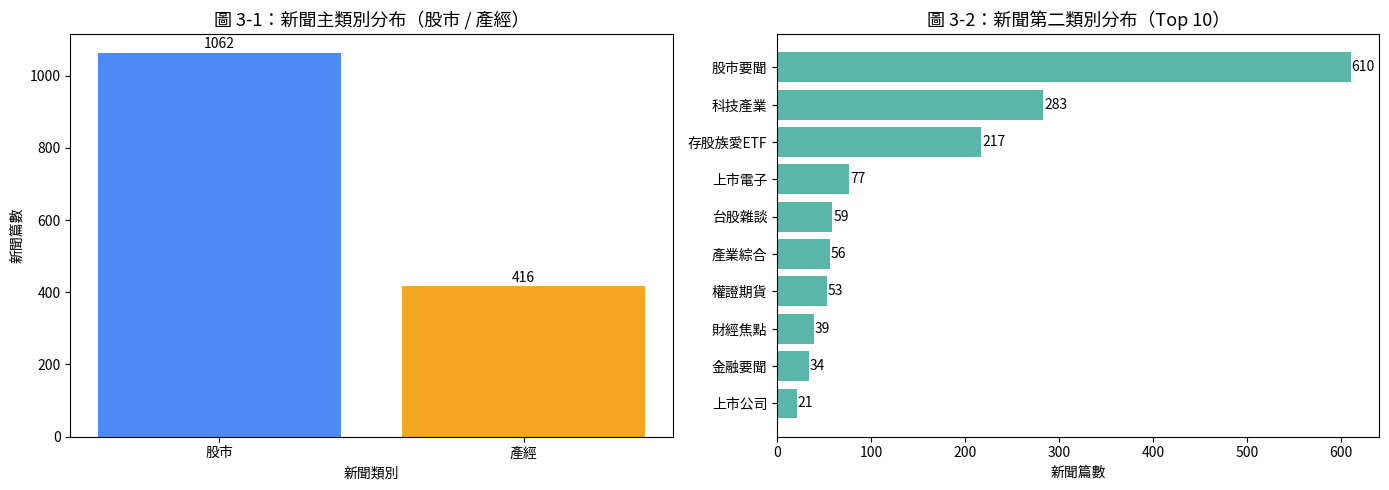

In [ ]:
# ============================================
# 圖 3：新聞主題／類別分布
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- 左圖：主類別（股市 / 產經）----
cat_counts = clean_df["artCatagory"].value_counts()
bars1 = axes[0].bar(cat_counts.index, cat_counts.values,
                    color=["#4C8BF5", "#F5A623"])
axes[0].set_title("圖 3-1：新聞主類別分布（股市 / 產經）",
                  fontproperties=zh_font, fontsize=13)
axes[0].set_xlabel("新聞類別", fontproperties=zh_font)
axes[0].set_ylabel("新聞篇數", fontproperties=zh_font)
axes[0].set_xticks(range(len(cat_counts)))
axes[0].set_xticklabels(cat_counts.index, fontproperties=zh_font)
for b in bars1:
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 5,
                 f"{int(b.get_height())}", ha="center", va="bottom",
                 fontproperties=zh_font)

# ---- 右圖：第二類別 Top 10 ----
sub_counts = clean_df["artSecondCategory"].value_counts().head(10)
bars2 = axes[1].barh(range(len(sub_counts)), sub_counts.values[::-1],
                     color="#5AB6A8")
axes[1].set_title("圖 3-2：新聞第二類別分布（Top 10）",
                  fontproperties=zh_font, fontsize=13)
axes[1].set_xlabel("新聞篇數", fontproperties=zh_font)
axes[1].set_yticks(range(len(sub_counts)))
axes[1].set_yticklabels(sub_counts.index[::-1], fontproperties=zh_font)
for i, b in enumerate(bars2):
    axes[1].text(b.get_width() + 1, b.get_y() + b.get_height() / 2,
                 f"{int(b.get_width())}", va="center",
                 fontproperties=zh_font)

plt.tight_layout()
plt.show()

#### 4-4 字詞共現網絡圖

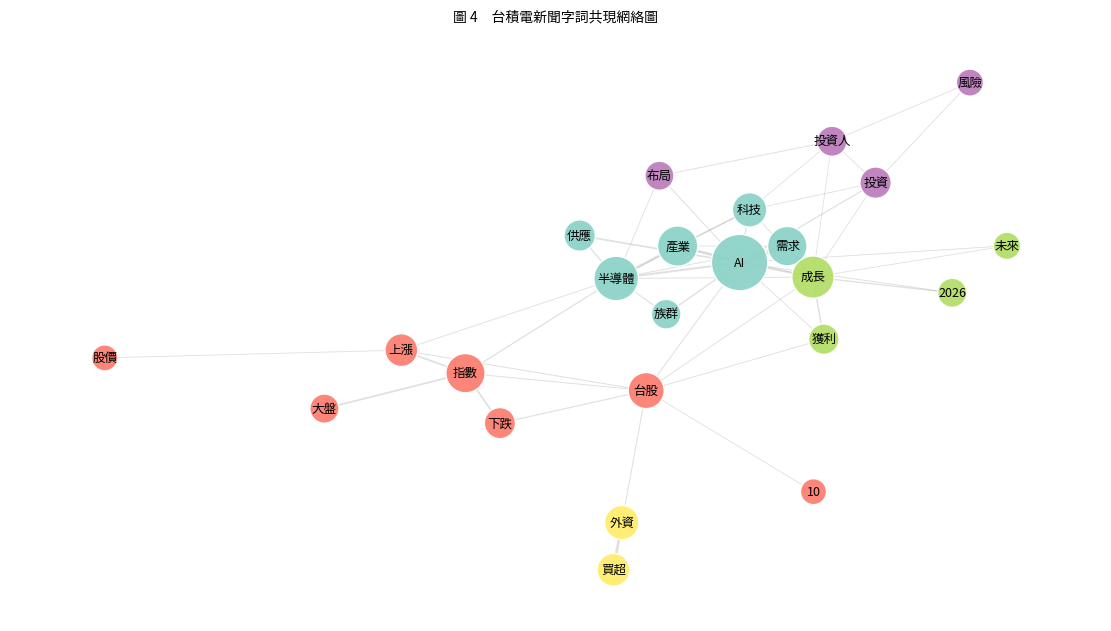

,source,target,weight
42,AI,需求,416
20,外資,買超,277
26,半導體,產業,223
40,AI,產業,181
5,AI,半導體,169
14,AI,成長,146
84,上漲,指數,145
145,大盤,指數,141
21,下跌,指數,137
44,AI,供應,136


In [ ]:
#### 4-4 字詞共現網絡圖（PPT 精簡版）

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from collections import Counter


# 排除缺乏分析意義的高頻詞
network_stopwords = {
    "記者", "報導", "表示", "指出", "認為", "強調",
    "今天", "昨日", "今年", "去年", "目前", "近期",
    "相關", "其中", "以及", "進行", "部分", "包括",
    "億元", "萬元", "百分比", "資料", "消息"
}

network_df = word_df[
    ~word_df["word"].isin(network_stopwords)
].copy()

network_df["word"] = (
    network_df["word"]
    .astype(str)
    .str.strip()
)

network_df = network_df[
    network_df["word"].str.len() > 1
].copy()


# 計算每個詞出現於多少篇不同新聞
document_frequency = (
    network_df[["system_id", "word"]]
    .drop_duplicates()
    .groupby("word")["system_id"]
    .nunique()
    .sort_values(ascending=False)
)


# 保留文件頻率最高的 25 個詞
top_n_words = 25

top_words = set(
    document_frequency
    .head(top_n_words)
    .index
)

network_df = network_df[
    network_df["word"].isin(top_words)
].copy()


# 整理每一句話內的不同詞彙
sentence_words = (
    network_df
    .groupby(["system_id", "sentence"])["word"]
    .apply(lambda words: sorted(set(words)))
)


# 計算同一句話中的詞彙配對
pair_counter = Counter()

for words in sentence_words:
    if len(words) >= 2:
        pair_counter.update(
            combinations(words, 2)
        )


# 建立連線資料
edge_df = pd.DataFrame(
    [
        {
            "source": pair[0],
            "target": pair[1],
            "weight": weight
        }
        for pair, weight in pair_counter.items()
    ]
)

if edge_df.empty:
    raise ValueError("沒有可建立的共現關係，請檢查 word_df。")


# 保留至少共現 3 次且最強的 50 條連線
edge_df = (
    edge_df[
        edge_df["weight"] >= 3
    ]
    .sort_values(
        "weight",
        ascending=False
    )
    .head(50)
    .copy()
)

if edge_df.empty:
    raise ValueError(
        "篩選後沒有連線，請將最小共現次數從 3 改為 2。"
    )


# 建立無向網絡
G = nx.from_pandas_edgelist(
    edge_df,
    source="source",
    target="target",
    edge_attr="weight",
    create_using=nx.Graph()
)


# 移除孤立節點
G.remove_nodes_from(
    list(nx.isolates(G))
)


# 偵測詞彙社群
communities = list(
    nx.community.greedy_modularity_communities(
        G,
        weight="weight"
    )
)

community_map = {
    node: community_id
    for community_id, community in enumerate(communities)
    for node in community
}

node_colors = [
    community_map.get(node, 0)
    for node in G.nodes()
]


# 節點大小：依加權連結程度調整
weighted_degree = dict(
    G.degree(weight="weight")
)

degree_values = np.array(
    [weighted_degree[node] for node in G.nodes()],
    dtype=float
)

node_sizes = (
    350
    + 1300
    * (degree_values - degree_values.min())
    / (degree_values.max() - degree_values.min() + 1e-9)
)


# 線條粗細：依共現次數調整
edge_weights = np.array(
    [
        G[u][v]["weight"]
        for u, v in G.edges()
    ],
    dtype=float
)

edge_widths = (
    0.4
    + 2.5
    * edge_weights
    / edge_weights.max()
)


# 固定位置，確保每次輸出一致
pos = nx.spring_layout(
    G,
    weight="weight",
    seed=42,
    k=1.0,
    iterations=300
)


# 建立適合 16:9 PPT 的橫式圖片
fig, ax = plt.subplots(
    figsize=(11, 6.2),
    facecolor="white"
)

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    width=edge_widths,
    edge_color="#999999",
    alpha=0.3
)

nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    edgecolors="white",
    linewidths=1,
    alpha=0.95
)

nx.draw_networkx_labels(
    G,
    pos,
    ax=ax,
    font_size=9,
    font_weight="bold",
    font_family=zh_font_name
)

ax.set_title(
    "圖 4　台積電新聞字詞共現網絡圖",
    fontsize=15,
    fontweight="bold",
    fontproperties=zh_font,
    pad=8
)

ax.axis("off")

plt.tight_layout(pad=0.3)

plt.savefig(
    "figure4_word_cooccurrence_network_ppt.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white"
)

plt.show()


# 輸出供 Gephi 或圖 5 使用
nx.write_graphml(
    G,
    "tsmc_word_cooccurrence_ppt.graphml"
)

display(edge_df.head(20))


##5.Degree centrality 前10名 Gephi圖與股價上漲日字詞網路圖

### 5-0 套件、路徑與資料準備

此段會自動檢查必要套件。資料路徑採用 `BASE_DIR` 管理：若在 `final_project` 資料夾內執行，會直接讀取目前資料夾；若在專案根目錄執行，會自動切到 `final_project`。Colab 若找不到 `news.csv` 或 `stock.csv`，會嘗試用下方 Google Drive ID 下載。


In [ ]:
# 5-0-1 安裝與匯入套件

import importlib.util
import subprocess
import sys

required_packages = {
    "jieba": "jieba",
    "networkx": "networkx",
    "matplotlib": "matplotlib",
    "pandas": "pandas",
    "gdown": "gdown",
    "IPython": "ipython",
}

for import_name, package_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            package_name,
            "-q",
        ])

from pathlib import Path
from collections import Counter
from itertools import combinations
import re

import gdown
import jieba
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = print

from matplotlib import font_manager


In [ ]:
# 5-0-2 設定資料路徑

BASE_DIR = Path.cwd()

# 支援兩種常見執行位置：
# 1. Colab / Jupyter 目前就在 final_project 資料夾
# 2. Colab / Jupyter 目前在專案根目錄，資料放在 final_project/
if not (BASE_DIR / "news.csv").exists() and (BASE_DIR / "final_project" / "news.csv").exists():
    BASE_DIR = BASE_DIR / "final_project"

NEWS_PATH = BASE_DIR / "news.csv"
STOCK_PATH = BASE_DIR / "stock.csv"
STOPWORDS_PATH = BASE_DIR / "stopwords.txt"
FONT_PATH = BASE_DIR / "sample_code" / "week15" / "TaipeiSansTCBeta-Regular.ttf"

OUTPUT_DIR = BASE_DIR / "data" / "network_figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


BASE_DIR: /content
OUTPUT_DIR: /content/data/network_figures


In [ ]:
# 5-0-3 Colab 資料下載備援
# 如果你已經把 news.csv、stock.csv 放在 notebook 同一層或 final_project/，此 cell 不會重新下載。

drive_files = {
    "news.csv": "1VzqhLJCGB-LLWbWLAH3jbASSNxY71jyb",
    "stock.csv": "1Ta5QWqcTRvFeRus_-C2WwdvR0X4ZQE6m",
}

for filename, file_id in drive_files.items():
    target_path = BASE_DIR / filename
    if not target_path.exists():
        url = f"https://drive.google.com/uc?id={file_id}"
        print(f"Downloading {filename} -> {target_path}")
        gdown.download(url, str(target_path), quiet=False)

print("news.csv exists:", NEWS_PATH.exists())
print("stock.csv exists:", STOCK_PATH.exists())
print("stopwords.txt exists:", STOPWORDS_PATH.exists(), "(optional)")


news.csv exists: True
stock.csv exists: True
stopwords.txt exists: True (optional)


### 5-1 文字清洗、斷詞與停用字

這裡統一台積電、輝達、AI 等關鍵詞寫法，並加入自訂詞，避免斷詞時被切碎。停用字優先讀取 `stopwords.txt`，若 Colab 沒有該檔案，也會使用本段內建的網絡分析停用字。


In [ ]:
# 5-1-1 自訂詞、替換字典與停用字

custom_words = [
    "台積電", "輝達", "半導體", "人工智慧", "先進製程", "晶圓代工",
    "供應鏈", "資本支出", "高效能運算", "CoWoS", "AI", "ETF"
]

for word in custom_words:
    jieba.add_word(word)

replace_dict = {
    "TSMC": "台積電",
    "tsmc": "台積電",
    "2330": "台積電",
    "台灣積體電路": "台積電",
    "台灣積體電路製造": "台積電",
    "NVIDIA": "輝達",
    "Nvidia": "輝達",
    "nvidia": "輝達",
    "AI": "人工智慧",
    "ai": "人工智慧",
}

network_stopwords = {
    "記者", "報導", "表示", "指出", "認為", "強調",
    "今天", "昨日", "今年", "去年", "目前", "近期",
    "相關", "其中", "以及", "進行", "部分", "包括",
    "億元", "萬元", "資料", "消息", "新聞", "台灣", "市場",
    "投資", "公司", "產品", "基金"
}

stopwords = set(network_stopwords)
if STOPWORDS_PATH.exists():
    stopwords.update(
        w.strip()
        for w in STOPWORDS_PATH.read_text(encoding="utf-8", errors="ignore").splitlines()
        if w.strip()
    )

print("stopwords size:", len(stopwords))


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 2.318 seconds.
DEBUG:jieba:Loading model cost 2.318 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


stopwords size: 1844


In [ ]:
# 5-1-2 文字處理函式

def normalize_text(text):
    text = str(text)
    for old, new in replace_dict.items():
        text = text.replace(old, new)
    text = re.sub(r"https?://\S+", " ", text)
    text = re.sub(r"[^\w\u4e00-\u9fff。！？；，、,.!?;]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def split_sentences(text):
    return [
        sentence.strip()
        for sentence in re.split(r"[。！？；.!?;]\s*", text)
        if sentence.strip()
    ]


def tokenize_sentence(sentence):
    words = []
    for word in jieba.lcut(sentence):
        word = word.strip()
        if len(word) <= 1:
            continue
        if word in stopwords:
            continue
        if re.fullmatch(r"\d+(\.\d+)?", word):
            continue
        if not re.search(r"[\u4e00-\u9fffA-Za-z]", word):
            continue
        words.append(word)
    return sorted(set(words))


### 5-2 載入新聞與股價資料

新聞資料會建立 `text_for_network` 作為網絡分析文字來源；股價資料會計算每日報酬率，並標記 `is_up_day`，供圖 6 篩選上漲日前後新聞。


In [ ]:
# 5-2-1 載入新聞資料

news = pd.read_csv(NEWS_PATH, encoding="utf-8-sig")
news["news_date"] = pd.to_datetime(news["artDate"], errors="coerce").dt.normalize()
news["text_for_network"] = (
    news["artTitle"].fillna("") + "。" + news["artContent"].fillna("")
).map(normalize_text)
news = news.dropna(subset=["news_date"]).copy()

print("news shape:", news.shape)
display(news[["system_id", "artTitle", "news_date", "artCatagory"]].head())


news shape: (1521, 9)


,system_id,artTitle,news_date,artCatagory
0,1,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,2026-03-04,產經
1,2,短期三因素干擾 新興市場長期魅力不減,2026-03-06,產經
2,3,台股2月定期定額：台積電、0050續創新高 高股息 ETF 與金控股消風,2026-03-10,產經
3,4,外匯存底有機會創高 外資匯出台積股息成關鍵,2026-02-01,產經
4,5,近年退撫基金績效表現佳 資產配置重押台積電,2026-02-01,產經


In [ ]:
# 5-2-2 載入股價資料並標記上漲日

stock = pd.read_csv(STOCK_PATH, encoding="utf-8-sig")
stock["date"] = pd.to_datetime(stock["日期"], errors="coerce").dt.normalize()

for col in ["收盤價", "開盤價", "最高價", "最低價", "漲跌價差"]:
    stock[col] = pd.to_numeric(
        stock[col].astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )

stock = stock.sort_values("date")
stock["return_1d"] = stock["收盤價"].pct_change()
stock["is_up_day"] = stock["return_1d"] > 0

print("stock shape:", stock.shape)
display(stock[["date", "收盤價", "return_1d", "is_up_day"]].head())


stock shape: (34, 12)


,date,收盤價,return_1d,is_up_day
0,2026-02-02,1765.0,NaN,False
1,2026-02-03,1800.0,0.019830,True
2,2026-02-04,1785.0,-0.008333,False
3,2026-02-05,1765.0,-0.011204,False
4,2026-02-06,1780.0,0.008499,True


### 5-3 建立共現網絡與繪圖函式

共現單位採「同一句話」：同一句中同時出現的詞會形成一條無向邊，邊權重為共現次數。中心性使用 `networkx.degree_centrality`，並另外保留加權 degree 方便解讀。


In [ ]:
# 5-3-1 建立共現網絡函式

def build_word_network(input_news, top_n_words=30, min_weight=3, max_edges=60):
    doc_words = {}
    sentence_word_rows = []

    for row in input_news.itertuples(index=False):
        doc_id = int(row.system_id)
        doc_words.setdefault(doc_id, set())

        for sentence in split_sentences(row.text_for_network):
            words = tokenize_sentence(sentence)
            if len(words) >= 2:
                sentence_word_rows.append((doc_id, words))
                doc_words[doc_id].update(words)

    document_frequency = Counter()
    for words in doc_words.values():
        document_frequency.update(words)

    top_words = {
        word
        for word, _ in document_frequency.most_common(top_n_words)
    }

    pair_counter = Counter()
    for _, words in sentence_word_rows:
        filtered_words = [word for word in words if word in top_words]
        if len(filtered_words) >= 2:
            pair_counter.update(combinations(filtered_words, 2))

    edge_rows = [
        {"source": source, "target": target, "weight": weight}
        for (source, target), weight in pair_counter.items()
        if weight >= min_weight
    ]

    if edge_rows:
        edge_df = (
            pd.DataFrame(edge_rows)
            .sort_values("weight", ascending=False)
            .head(max_edges)
            .reset_index(drop=True)
        )
    else:
        edge_df = pd.DataFrame(
            [
                {"source": source, "target": target, "weight": weight}
                for (source, target), weight in pair_counter.most_common(max_edges)
            ]
        )

    graph = nx.Graph()
    for row in edge_df.itertuples(index=False):
        graph.add_edge(row.source, row.target, weight=float(row.weight))

    graph.remove_nodes_from(list(nx.isolates(graph)))

    degree_centrality = nx.degree_centrality(graph)
    weighted_degree = dict(graph.degree(weight="weight"))

    centrality_df = (
        pd.DataFrame(
            {
                "word": list(graph.nodes()),
                "degree_centrality": [degree_centrality[node] for node in graph.nodes()],
                "weighted_degree": [weighted_degree[node] for node in graph.nodes()],
            }
        )
        .sort_values(["degree_centrality", "weighted_degree"], ascending=False)
        .reset_index(drop=True)
    )

    return graph, edge_df, centrality_df


In [ ]:
# 5-3-2 繪製網絡圖函式

def draw_network(graph, title, output_png, highlight_nodes=None):
    if graph.number_of_nodes() == 0:
        raise ValueError("網絡沒有節點，無法繪圖。")

    highlight_nodes = highlight_nodes or set()
    weighted_degree = dict(graph.degree(weight="weight"))
    max_degree = max(weighted_degree.values()) if weighted_degree else 1

    node_sizes = [
        450 + 1800 * weighted_degree[node] / max_degree
        for node in graph.nodes()
    ]
    node_colors = [
        "#E45756" if node in highlight_nodes else "#4C78A8"
        for node in graph.nodes()
    ]

    edge_weights = [graph[u][v]["weight"] for u, v in graph.edges()]
    max_weight = max(edge_weights) if edge_weights else 1
    edge_widths = [
        0.6 + 3.0 * weight / max_weight
        for weight in edge_weights
    ]

    pos = nx.spring_layout(
        graph,
        weight="weight",
        seed=42,
        k=0.9,
        iterations=300,
    )

    fig, ax = plt.subplots(figsize=(11, 6.2), facecolor="white")

    nx.draw_networkx_edges(
        graph,
        pos,
        width=edge_widths,
        edge_color="#8A8F98",
        alpha=0.35,
        ax=ax,
    )
    nx.draw_networkx_nodes(
        graph,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="white",
        linewidths=1.2,
        alpha=0.96,
        ax=ax,
    )
    nx.draw_networkx_labels(
        graph,
        pos,
        font_size=10,
        font_weight="bold",
        font_family=zh_font.get_name() if zh_font else None,
        ax=ax,
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        fontproperties=zh_font,
        pad=8,
    )
    ax.axis("off")
    plt.tight_layout(pad=0.3)
    fig.savefig(output_png, dpi=300, bbox_inches="tight", pad_inches=0.05)
    plt.show()


### 5-4 圖 5：Degree centrality 前10名 Gephi圖（無向圖）

此圖先用全部新聞建立字詞共現網絡，再取 degree centrality 前 10 名詞彙形成子圖。`graphml` 可匯入 Gephi 進一步排版。


In [ ]:
# 5-4-1 建立整體新聞字詞網絡

overall_graph, figure5_edges, figure5_centrality = build_word_network(
    news,
    top_n_words=30,
    min_weight=3,
    max_edges=60,
)

figure5_top10_words = set(figure5_centrality.head(10)["word"])
figure5_graph = overall_graph.subgraph(figure5_top10_words).copy()

display(figure5_centrality.head(10))
display(figure5_edges.head(10))


,word,degree_centrality,weighted_degree
0,台積電,0.916667,4707.0
1,人工智慧,0.666667,4325.0
2,台股,0.416667,2032.0
3,需求,0.291667,1644.0
4,半導體,0.291667,1523.0
5,產業,0.250000,1287.0
6,成長,0.250000,1182.0
7,指數,0.208333,1149.0
8,族群,0.166667,637.0
9,晶片,0.125000,706.0


,source,target,weight
0,人工智慧,需求,564
1,人工智慧,台積電,496
2,台積電,台股,419
3,人工智慧,晶片,360
4,人工智慧,成長,356
5,台股,指數,349
6,人工智慧,產業,335
7,人工智慧,半導體,334
8,半導體,台積電,302
9,人工智慧,供應鏈,297


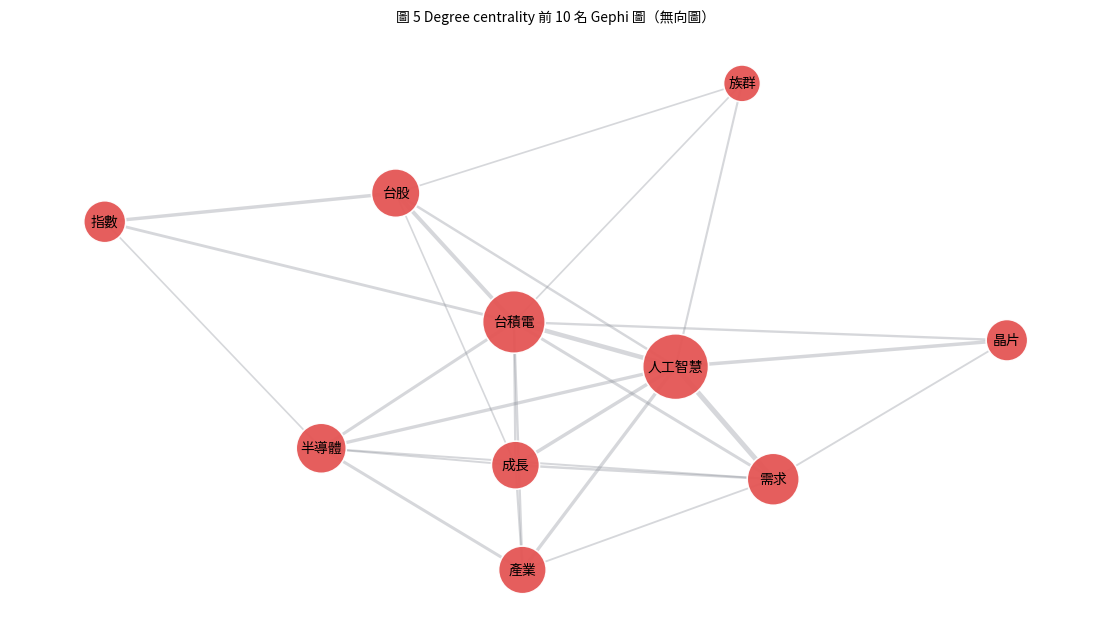

圖 5 已輸出： /content/data/network_figures/figure5_degree_centrality_top10.png


In [ ]:
# 5-4-2 繪製並輸出圖 5

figure5_png = OUTPUT_DIR / "figure5_degree_centrality_top10.png"

draw_network(
    figure5_graph,
    "圖 5 Degree centrality 前 10 名 Gephi 圖（無向圖）",
    figure5_png,
    highlight_nodes=figure5_top10_words,
)

figure5_edges.to_csv(
    OUTPUT_DIR / "figure5_overall_edges.csv",
    index=False,
    encoding="utf-8-sig",
)
figure5_centrality.to_csv(
    OUTPUT_DIR / "figure5_degree_centrality.csv",
    index=False,
    encoding="utf-8-sig",
)
nx.write_graphml(overall_graph, OUTPUT_DIR / "figure5_overall_network.graphml")
nx.write_graphml(figure5_graph, OUTPUT_DIR / "figure5_degree_top10_network.graphml")

print("圖 5 已輸出：", figure5_png)


##6.股價上漲日附近新聞的字詞網路圖

此圖先找出股價上漲交易日，再納入上漲日前後一天的新聞。這個設計可以觀察股價正向變動附近，新聞文字網絡是否更集中在 AI、半導體、資金面等題材。


In [ ]:
# 篩選股價上漲日前後一天新聞

up_dates = set(stock.loc[stock["is_up_day"], "date"])
nearby_dates = set()

for date in up_dates:
    nearby_dates.update(
        pd.date_range(
            date - pd.Timedelta(days=1),
            date + pd.Timedelta(days=1),
        )
    )

up_news = news[news["news_date"].isin(nearby_dates)].copy()

print("股價上漲交易日數：", len(up_dates))
print("上漲日前後一天新聞篇數：", len(up_news))
display(up_news[["system_id", "artTitle", "news_date", "artCatagory"]].head())


股價上漲交易日數： 13
上漲日前後一天新聞篇數： 1074


,system_id,artTitle,news_date,artCatagory
0,1,台股崩跌千點該逃嗎？十大崩盤回顧告訴你「財富自由」密碼,2026-03-04,產經
1,2,短期三因素干擾 新興市場長期魅力不減,2026-03-06,產經
2,3,台股2月定期定額：台積電、0050續創新高 高股息 ETF 與金控股消風,2026-03-10,產經
5,6,太空、資安與半導體 新創獲投資破千億,2026-02-02,產經
6,7,勞動基金去年大賺1.1兆！新制勞退十大持股 台積電穩居第一,2026-02-02,產經


In [ ]:
# 建立圖 6 字詞網絡

figure6_graph, figure6_edges, figure6_centrality = build_word_network(
    up_news,
    top_n_words=35,
    min_weight=2,
    max_edges=70,
)

display(figure6_centrality.head(10))
display(figure6_edges.head(10))


,word,degree_centrality,weighted_degree
0,台積電,0.821429,3594.0
1,人工智慧,0.678571,3473.0
2,台股,0.428571,1825.0
3,成長,0.285714,1036.0
4,需求,0.250000,1172.0
5,半導體,0.214286,1002.0
6,產業,0.214286,963.0
7,ETF,0.214286,728.0
8,指數,0.178571,760.0
9,族群,0.142857,486.0


,source,target,weight
0,人工智慧,需求,418
1,人工智慧,台積電,342
2,台積電,台股,329
3,人工智慧,成長,267
4,台股,指數,257
5,人工智慧,產業,255
6,人工智慧,晶片,251
7,人工智慧,半導體,241
8,人工智慧,供應鏈,218
9,半導體,台積電,216


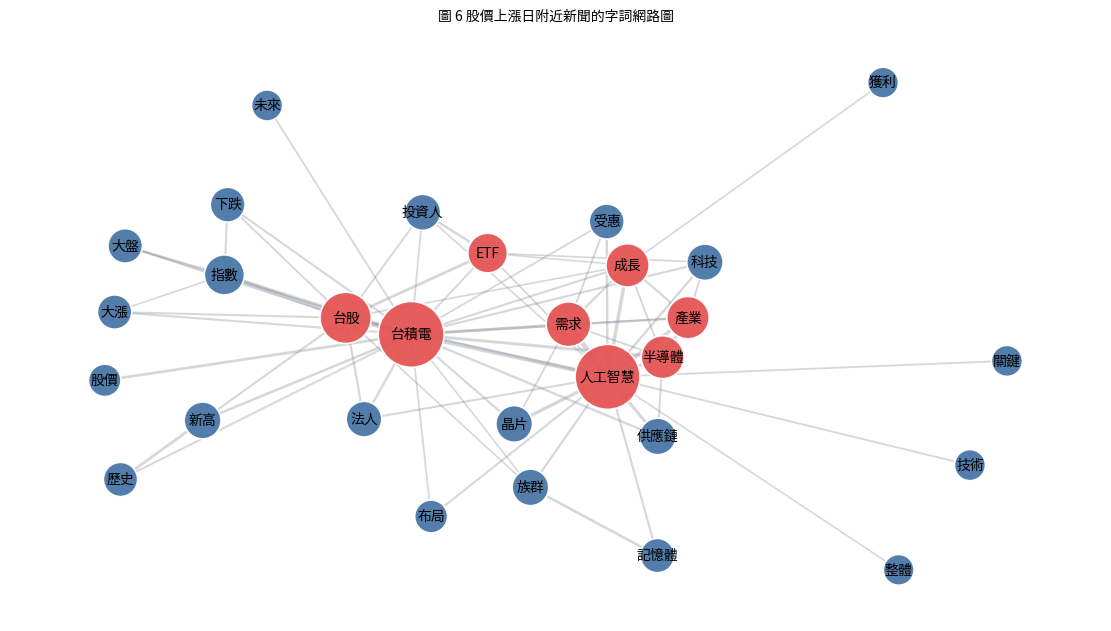

圖 6 已輸出： /content/data/network_figures/figure6_upday_word_network.png


In [ ]:
# 繪製並輸出圖 6

figure6_png = OUTPUT_DIR / "figure6_upday_word_network.png"

draw_network(
    figure6_graph,
    "圖 6 股價上漲日附近新聞的字詞網路圖",
    figure6_png,
    highlight_nodes=set(figure6_centrality.head(8)["word"]),
)

figure6_edges.to_csv(
    OUTPUT_DIR / "figure6_upday_edges.csv",
    index=False,
    encoding="utf-8-sig",
)
figure6_centrality.to_csv(
    OUTPUT_DIR / "figure6_upday_degree_centrality.csv",
    index=False,
    encoding="utf-8-sig",
)
nx.write_graphml(figure6_graph, OUTPUT_DIR / "figure6_upday_word_network.graphml")

print("圖 6 已輸出：", figure6_png)


### 6-1 輸出檔案檢查

所有圖檔、中心性表、edge list 與 Gephi 可用的 GraphML 都會放在 `data/network_figures/`。


In [ ]:
# 5-6-1 檢查輸出檔案

output_files = sorted(OUTPUT_DIR.glob("*"))

output_summary = pd.DataFrame(
    {
        "file": [path.name for path in output_files],
        "size_kb": [round(path.stat().st_size / 1024, 1) for path in output_files],
    }
)

display(output_summary)


,file,size_kb
0,figure5_degree_centrality.csv,0.7
1,figure5_degree_centrality_top10.png,314.0
2,figure5_degree_top10_network.graphml,2.7
3,figure5_overall_edges.csv,1.3
4,figure5_overall_network.graphml,5.6
5,figure6_upday_degree_centrality.csv,1.0
6,figure6_upday_edges.csv,1.4
7,figure6_upday_word_network.graphml,6.4
8,figure6_upday_word_network.png,510.2


In [ ]:
# 5-6-2 Colab 下載輸出資料夾（需要時再執行）

# from google.colab import files
# import shutil
#
# zip_path = shutil.make_archive(
#     str(OUTPUT_DIR),
#     "zip",
#     root_dir=OUTPUT_DIR,
# )
# files.download(zip_path)


# 股價資料

## 1.載入資料

In [ ]:
NEWS_PATH = "stock.csv"

stock = pd.read_csv(NEWS_PATH)

# 日期轉換
stock["日期"] = pd.to_datetime(stock["日期"])

# 數值欄位清理：移除逗號、轉成數字
num_cols = [
    "成交股數", "成交金額", "開盤價", "最高價", "最低價",
    "收盤價", "漲跌價差", "成交筆數"
]

for col in num_cols:
    stock[col] = (
        stock[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("--", "", regex=False)
    )
    stock[col] = pd.to_numeric(stock[col], errors="coerce")

# 依日期排序，確保 shift 計算正確
stock = stock.sort_values("日期").reset_index(drop=True)

## 2.計算股價報酬率欄位

In [ ]:
# 今日收盤價相對昨日收盤價變化
stock["return_1d"] = (
    stock["收盤價"] - stock["收盤價"].shift(1)
) / stock["收盤價"].shift(1)

# 明日收盤價相對今日收盤價變化
stock["return_next_1d"] = (
    stock["收盤價"].shift(-1) - stock["收盤價"]
) / stock["收盤價"]

# 三個交易日後收盤價相對今日收盤價變化
stock["return_next_3d"] = (
    stock["收盤價"].shift(-3) - stock["收盤價"]
) / stock["收盤價"]

# 當日股價波動
stock["intraday_range"] = stock["最高價"] - stock["最低價"]

## 3.保留合併需要的股價欄位

In [ ]:
stock_for_merge = stock.rename(columns={
    "日期": "date",
    "收盤價": "close",
    "成交股數": "volume",
    "成交筆數": "trade_count"
})[
    [
        "date",
        "close",
        "volume",
        "trade_count",
        "intraday_range", ## 當日股價波動
        "return_1d", ## 今日收盤價相對昨日收盤價變化
        "return_next_1d", ## 明日收盤價相對今日收盤價變化
        "return_next_3d" ## 三個交易日後收盤價相對今日收盤價變化
    ]
]

stock_for_merge.head()

,date,close,volume,trade_count,intraday_range,return_1d,return_next_1d,return_next_3d
0,2026-02-02,1765.0,33342359,227693,20.0,NaN,0.019830,0.000000
1,2026-02-03,1800.0,30386718,63370,25.0,0.019830,-0.008333,-0.011111
2,2026-02-04,1785.0,29087857,89612,30.0,-0.008333,-0.011204,0.016807
3,2026-02-05,1765.0,28974303,119686,20.0,-0.011204,0.008499,0.065156
4,2026-02-06,1780.0,36484181,117607,40.0,0.008499,0.019663,0.075843


In [ ]:
stock_for_merge.to_csv(
    "stock_for_merge.csv",
    index=False,
    encoding="utf-8-sig"
)

from google.colab import files

files.download("stock_for_merge.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4.合併新聞與股價資料

In [ ]:
files = {
    "lexicon_article.csv": "1jXz1jrmsp56apK_NCAUv6eR0JSGV68cO"
}
for filename, file_id in files.items():
    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"Downloading {filename}...")
    gdown.download(url, filename, quiet=False)


NEWS_PATH = "lexicon_article.csv"

sentiment_article = pd.read_csv(NEWS_PATH)


Downloading...
From: https://drive.google.com/uc?id=1jXz1jrmsp56apK_NCAUv6eR0JSGV68cO
To: /content/lexicon_article.csv
100%|██████████| 8.22M/8.22M [00:00<00:00, 145MB/s]


In [ ]:
# 日期欄位轉換
sentiment_article["news_date"] = pd.to_datetime(sentiment_article["news_date"])

daily_sentiment = (
    sentiment_article
    .groupby("news_date")
    .agg(
        news_count=("sentiment_label", "count"),
        avg_sentiment=("sentiment_score", "mean"),
        label_ratio=("sentiment_label", lambda x: (x == "positive").mean())
    )
    .reset_index()
    .rename(columns={"news_date": "date"})
)


# 合併情緒資料與股價資料
final_data = pd.merge(
    daily_sentiment,
    stock_for_merge,
    on="date",
    how="left"
)

# 最終保留欄位
final_data = final_data[
    [
        "date",
        "news_count",
        "avg_sentiment",
        "label_ratio",
        "close",
        "return_1d",
        "return_next_1d",
        "return_next_3d"
    ]
]
final_data.head()

,date,news_count,avg_sentiment,label_ratio,close,return_1d,return_next_1d,return_next_3d
0,2026-02-01,18,0.488071,0.833333,NaN,NaN,NaN,NaN
1,2026-02-02,51,0.339193,0.725490,1765.0,NaN,0.019830,0.000000
2,2026-02-03,39,0.409385,0.820513,1800.0,0.019830,-0.008333,-0.011111
3,2026-02-04,27,0.369222,0.740741,1785.0,-0.008333,-0.011204,0.016807
4,2026-02-05,46,0.357650,0.760870,1765.0,-0.011204,0.008499,0.065156


In [ ]:
final_data.to_csv(
    "merge_data.csv",
    index=False,
    encoding="utf-8-sig"
)

from google.colab import files

files.download("merge_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ⭐️資料說明

報告：[Canva](https://canva.link/1ni8reh3hvslgzv)

整理資料如下：<br>

1. 原始資料_新聞：news.csv<br>
2. 原始資料_股票：stock.csv<br>
3. 整理後_新聞情緒分析的資料集：lexicon_article.csv<br>
4. 整理後_股票資料集：stock_for_merge.csv<br>
5. 要讀取新聞情緒、股價變化彙整日統計表：merge_data.csv(call下方程式碼)

    ```
    files = {
        "merge_data.csv": "1SmunmlrpObTrvfqWXiVsW3dl5HFT6IVE"
    }
    for filename, file_id in files.items():
        url = f"https://drive.google.com/uc?id={file_id}"
        print(f"Downloading {filename}...")
        gdown.download(url, filename, quiet=False)


    NEWS_PATH = "merge_data.csv"

    merge_data = pd.read_csv(NEWS_PATH)

    ```
<br>
各資料集網址代碼如下：


```
    "news.csv": "1VzqhLJCGB-LLWbWLAH3jbASSNxY71jyb",
    "stock.csv": "1Ta5QWqcTRvFeRus_-C2WwdvR0X4ZQE6m",
    "lexicon_article.csv": "1jXz1jrmsp56apK_NCAUv6eR0JSGV68cO",
    "stock_for_merge.csv": "1RweqSB6SA6Gyrt39ji0HzM6HxzE2iAWI",
```

